# Phase 3 — Linguistically-Aware Router

**Goal:** Train a lightweight classifier (the *router*) that examines:
1. **Linguistic features** of each input sentence
2. **Small-model confidence signals** (confidence, entropy, margin from finetuned TinyBERT)

…and decides whether the small model's prediction is trustworthy or whether the sample
should be *escalated* to the larger model (finetuned RoBERTa-large).

### Train / Inference split
- **Training:** val split — we have both TinyBERT and RoBERTa predictions, so we can
  construct oracle escalation labels.
- **Inference:** test split — the router only sees linguistic features + TinyBERT signals.
  Large-model predictions on test are used **only for evaluation**, not as router input.

### Oracle label construction (val set)
- `escalate = 0` → small model is already correct **or** the large model would not help.
- `escalate = 1` → the small model is wrong **and** the large model is correct.

### Classifiers tried
- Logistic Regression
- Random Forest
- Gradient Boosting (`HistGradientBoosting`)
- Support Vector Machine (SVM)
- Multi-Layer Perceptron (MLP)

### Routing simulation (test set)
- If router says *keep* → use small model prediction.
- If router says *escalate* → use large model prediction.
- Compare vs small-only / large-only / oracle baselines.

---

## 1. Setup

In [16]:
%%capture
!pip install -q scikit-learn matplotlib seaborn python-dotenv

In [17]:
import os, re, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, f1_score, roc_auc_score, RocCurveDisplay
)

from dotenv import dotenv_values

sns.set_theme(style='whitegrid', font_scale=1.1)
pd.set_option('display.max_columns', 40)

print('Imports OK')

Imports OK


## 2. Load paths from `.env`

In [18]:
raw_env = dotenv_values(os.path.join(os.getcwd(), '.env'))

def _resolve(val: str, env: dict) -> str:
    """Expand ${VAR} references inside .env values."""
    prev = None
    while prev != val:
        prev = val
        val = re.sub(r'\$\{(\w+)\}', lambda m: env.get(m.group(1), m.group(0)), val)
    return val

env = {k: _resolve(v, raw_env) for k, v in raw_env.items()}

PROJECT_DIR            = env['PROJECT_DIR']
COMBINED_DATA_DIR      = env['COMBINED_DATA_DIR']
VAL_CSV                = env['VAL_CSV']
TEST_CSV               = env['TEST_CSV']
LING_FEATURES_CSV      = env['LING_FEATURES_CSV']
SMALL_VAL_PREDS_CSV    = env['SMALL_MODEL_VAL_PREDS_CSV']
SMALL_TEST_PREDS_CSV   = env['SMALL_MODEL_TEST_PREDS_CSV']
LARGE_VAL_PREDS_CSV    = env['LARGE_MODEL_VAL_PREDS_CSV']
LARGE_TEST_PREDS_CSV   = env['LARGE_MODEL_TEST_PREDS_CSV']
ROUTER_OUTPUT_DIR      = env['ROUTER_OUTPUT_DIR']

os.makedirs(ROUTER_OUTPUT_DIR, exist_ok=True)

for tag, p in [
    ('VAL_CSV',            VAL_CSV),
    ('TEST_CSV',           TEST_CSV),
    ('LING_FEATURES',      LING_FEATURES_CSV),
    ('SMALL_VAL_PREDS',    SMALL_VAL_PREDS_CSV),
    ('SMALL_TEST_PREDS',   SMALL_TEST_PREDS_CSV),
    ('LARGE_VAL_PREDS',    LARGE_VAL_PREDS_CSV),
    ('LARGE_TEST_PREDS',   LARGE_TEST_PREDS_CSV),
]:
    assert os.path.isfile(p), f'{tag} not found: {p}'
    print(f'{tag:20s} → {p}')

print(f'{"ROUTER_OUT":20s} → {ROUTER_OUTPUT_DIR}')

VAL_CSV              → /Users/tejeshwinirs/Documents/Projects/UMN/NLP/Linguistically-aware-model-routing-for-financial-sentiment-analysis/data/combined_data/val.csv
TEST_CSV             → /Users/tejeshwinirs/Documents/Projects/UMN/NLP/Linguistically-aware-model-routing-for-financial-sentiment-analysis/data/combined_data/test.csv
LING_FEATURES        → /Users/tejeshwinirs/Documents/Projects/UMN/NLP/Linguistically-aware-model-routing-for-financial-sentiment-analysis/data/combined_data/processed_phrasebank.csv
SMALL_VAL_PREDS      → /Users/tejeshwinirs/Documents/Projects/UMN/NLP/Linguistically-aware-model-routing-for-financial-sentiment-analysis/Output/model_outputs/Finetuned TinyBert/with Combined Dataset/finetuned_TinyBERT_General_4L_312D_val_predictions.csv
SMALL_TEST_PREDS     → /Users/tejeshwinirs/Documents/Projects/UMN/NLP/Linguistically-aware-model-routing-for-financial-sentiment-analysis/Output/model_outputs/Finetuned TinyBert/with Combined Dataset/finetuned_TinyBERT_General_4L_31

## 3. Constants

In [19]:
LINGUISTIC_FEATURES = [
    'token_count', 'char_count', 'avg_word_len',
    'dep_depth', 'num_clauses', 'passive_voice_count',
    'negation_count', 'hedge_count', 'num_financial_terms',
    'num_entities', 'entity_density',
    'flesch_reading_ease', 'flesch_kincaid_grade', 'complexity_score',
]

ROUTER_FEATURES = LINGUISTIC_FEATURES + [
    'small_confidence', 'small_entropy', 'small_margin'
]

LABEL2ID = {'negative': 0, 'neutral': 1, 'positive': 2}
LABEL_NAMES = ['negative', 'neutral', 'positive']

print(f'Router features ({len(ROUTER_FEATURES)}):')
for i, f in enumerate(ROUTER_FEATURES, 1):
    print(f'  {i:2d}. {f}')

Router features (17):
   1. token_count
   2. char_count
   3. avg_word_len
   4. dep_depth
   5. num_clauses
   6. passive_voice_count
   7. negation_count
   8. hedge_count
   9. num_financial_terms
  10. num_entities
  11. entity_density
  12. flesch_reading_ease
  13. flesch_kincaid_grade
  14. complexity_score
  15. small_confidence
  16. small_entropy
  17. small_margin


## 4. Helper — build merged dataframe

In [20]:
def build_merged_df(split_csv, small_preds_csv, large_preds_csv=None):
    """
    Merge linguistic features (from the split CSV) with small-model predictions.
    If large_preds_csv is provided, also merge large-model predictions and
    compute the oracle escalation label.
    """
    df_split = pd.read_csv(split_csv)
    df_small = pd.read_csv(small_preds_csv)

    df_ling = df_split[['id'] + LINGUISTIC_FEATURES].copy()

    df_sm = df_small[['id', 'true_label', 'predicted_label',
                       'confidence', 'entropy', 'margin']].copy()
    df_sm.rename(columns={
        'predicted_label': 'small_pred',
        'confidence':      'small_confidence',
        'entropy':         'small_entropy',
        'margin':          'small_margin',
    }, inplace=True)

    df = df_ling.merge(df_sm, on='id', how='inner')
    df['small_correct'] = (df['small_pred'] == df['true_label']).astype(int)

    if large_preds_csv is not None:
        df_lg = pd.read_csv(large_preds_csv)[['id', 'pred_label', 'correct']].copy()
        df_lg.rename(columns={'pred_label': 'large_pred', 'correct': 'large_correct'}, inplace=True)
        df = df.merge(df_lg, on='id', how='inner')
        df['large_correct'] = df['large_correct'].astype(int)
        df['escalate'] = ((df['small_correct'] == 0) & (df['large_correct'] == 1)).astype(int)

    assert len(df) == len(df_split), f'Row count mismatch: {len(df)} vs {len(df_split)}'
    return df

## 5. Build training set (val split)

In [21]:
df_train = build_merged_df(VAL_CSV, SMALL_VAL_PREDS_CSV, LARGE_VAL_PREDS_CSV)

print(f'Training set shape : {df_train.shape}')
print(f'\nEscalation label distribution (val):')
print(df_train['escalate'].value_counts())
print(f'Escalation rate: {df_train["escalate"].mean():.2%}')

Training set shape : (6223, 24)

Escalation label distribution (val):
escalate
0    5437
1     786
Name: count, dtype: int64
Escalation rate: 12.63%


In [22]:
print('Breakdown of small-model errors (val):')
small_wrong = df_train[df_train['small_correct'] == 0]
print(f'  Total small-model errors : {len(small_wrong)}')
print(f'  Large model fixes them   : {small_wrong["large_correct"].sum()} '
      f'({small_wrong["large_correct"].mean():.1%})')
print(f'  Both models wrong        : {(small_wrong["large_correct"] == 0).sum()}')

Breakdown of small-model errors (val):
  Total small-model errors : 1301
  Large model fixes them   : 786 (60.4%)
  Both models wrong        : 515


In [23]:
X_train = df_train[ROUTER_FEATURES].values
y_train = df_train['escalate'].values

print(f'X_train : {X_train.shape}')
print(f'y_train balance : {np.bincount(y_train)}  (0=keep, 1=escalate)')

X_train : (6223, 17)
y_train balance : [5437  786]  (0=keep, 1=escalate)


## 6. Train & compare router classifiers (5-fold CV on val)

In [24]:
classifiers = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced',
                                   random_state=42)),
    ]),
    'Random Forest': Pipeline([
        ('clf', RandomForestClassifier(
            n_estimators=300, max_depth=10, class_weight='balanced',
            random_state=42, n_jobs=-1)),
    ]),
    'Gradient Boosting': Pipeline([
        ('clf', HistGradientBoostingClassifier(
            max_iter=300, max_depth=6, learning_rate=0.1,
            class_weight='balanced', random_state=42)),
    ]),
    'SVM (RBF)': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel='rbf', class_weight='balanced',
                     probability=True, random_state=42)),
    ]),
    'MLP': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', MLPClassifier(
            hidden_layer_sizes=(128, 64), max_iter=500,
            early_stopping=True, random_state=42)),
    ]),
}

In [25]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'f1', 'precision', 'recall', 'roc_auc']

cv_results = {}
for name, pipe in classifiers.items():
    print(f'Training {name} …')
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring,
                            return_train_score=False, n_jobs=-1)
    cv_results[name] = scores
    print(f'  Accuracy : {scores["test_accuracy"].mean():.4f} ± {scores["test_accuracy"].std():.4f}')
    print(f'  F1       : {scores["test_f1"].mean():.4f} ± {scores["test_f1"].std():.4f}')
    print(f'  ROC-AUC  : {scores["test_roc_auc"].mean():.4f} ± {scores["test_roc_auc"].std():.4f}')
    print()

Training Logistic Regression …
  Accuracy : 0.7194 ± 0.0143
  F1       : 0.4016 ± 0.0176
  ROC-AUC  : 0.7923 ± 0.0131

Training Random Forest …
  Accuracy : 0.7901 ± 0.0092
  F1       : 0.3976 ± 0.0291
  ROC-AUC  : 0.7888 ± 0.0173

Training Gradient Boosting …
  Accuracy : 0.8075 ± 0.0131
  F1       : 0.3284 ± 0.0182
  ROC-AUC  : 0.7548 ± 0.0129

Training SVM (RBF) …
  Accuracy : 0.7062 ± 0.0225
  F1       : 0.3831 ± 0.0189
  ROC-AUC  : 0.7712 ± 0.0145

Training MLP …
  Accuracy : 0.8732 ± 0.0019
  F1       : 0.0099 ± 0.0121
  ROC-AUC  : 0.6606 ± 0.1099



In [26]:
summary_rows = []
for name, scores in cv_results.items():
    summary_rows.append({
        'Classifier': name,
        'Accuracy':   f"{scores['test_accuracy'].mean():.4f} ± {scores['test_accuracy'].std():.4f}",
        'F1':         f"{scores['test_f1'].mean():.4f} ± {scores['test_f1'].std():.4f}",
        'Precision':  f"{scores['test_precision'].mean():.4f} ± {scores['test_precision'].std():.4f}",
        'Recall':     f"{scores['test_recall'].mean():.4f} ± {scores['test_recall'].std():.4f}",
        'ROC-AUC':    f"{scores['test_roc_auc'].mean():.4f} ± {scores['test_roc_auc'].std():.4f}",
        '_f1_mean':   scores['test_f1'].mean(),
    })

df_summary = pd.DataFrame(summary_rows).sort_values('_f1_mean', ascending=False)
display(df_summary.drop(columns='_f1_mean').reset_index(drop=True))

,Classifier,Accuracy,F1,Precision,Recall,ROC-AUC
0,Logistic Regression,0.7194 ± 0.0143,0.4016 ± 0.0176,0.2751 ± 0.0128,0.7456 ± 0.0479,0.7923 ± 0.0131
1,Random Forest,0.7901 ± 0.0092,0.3976 ± 0.0291,0.3119 ± 0.0172,0.5510 ± 0.0652,0.7888 ± 0.0173
2,SVM (RBF),0.7062 ± 0.0225,0.3831 ± 0.0189,0.2614 ± 0.0169,0.7202 ± 0.0329,0.7712 ± 0.0145
3,Gradient Boosting,0.8075 ± 0.0131,0.3284 ± 0.0182,0.2952 ± 0.0266,0.3715 ± 0.0091,0.7548 ± 0.0129
4,MLP,0.8732 ± 0.0019,0.0099 ± 0.0121,0.2444 ± 0.3875,0.0051 ± 0.0062,0.6606 ± 0.1099


## 7. Retrain best router on full val set

In [27]:
best_name = df_summary.iloc[0]['Classifier']
print(f'Best router by F1: {best_name}')

best_pipe = classifiers[best_name]
best_pipe.fit(X_train, y_train)

y_train_pred = best_pipe.predict(X_train)
y_train_prob = best_pipe.predict_proba(X_train)[:, 1]

print(f'\n--- {best_name} on training (val) set ---')
print(classification_report(y_train, y_train_pred, target_names=['keep', 'escalate']))

Best router by F1: Logistic Regression

--- Logistic Regression on training (val) set ---
              precision    recall  f1-score   support

        keep       0.95      0.72      0.82      5437
    escalate       0.28      0.75      0.40       786

    accuracy                           0.72      6223
   macro avg       0.61      0.73      0.61      6223
weighted avg       0.87      0.72      0.76      6223



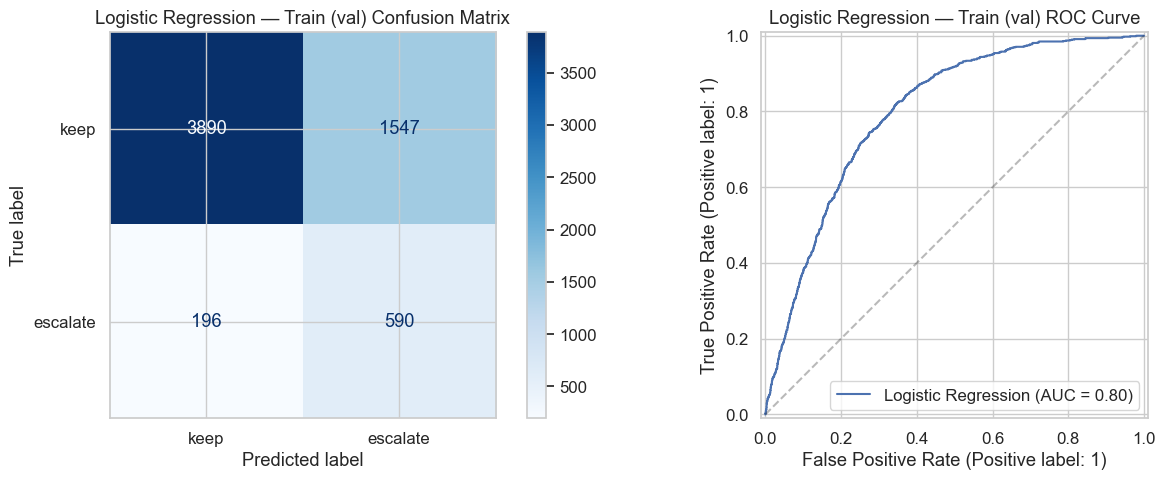

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_train, y_train_pred, display_labels=['keep', 'escalate'],
    cmap='Blues', ax=axes[0])
axes[0].set_title(f'{best_name} — Train (val) Confusion Matrix')

RocCurveDisplay.from_predictions(y_train, y_train_prob, ax=axes[1], name=best_name)
axes[1].set_title(f'{best_name} — Train (val) ROC Curve')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(ROUTER_OUTPUT_DIR, 'router_train_eval.png'), dpi=150,
            bbox_inches='tight')
plt.show()

## 8. Feature importance (trained router)

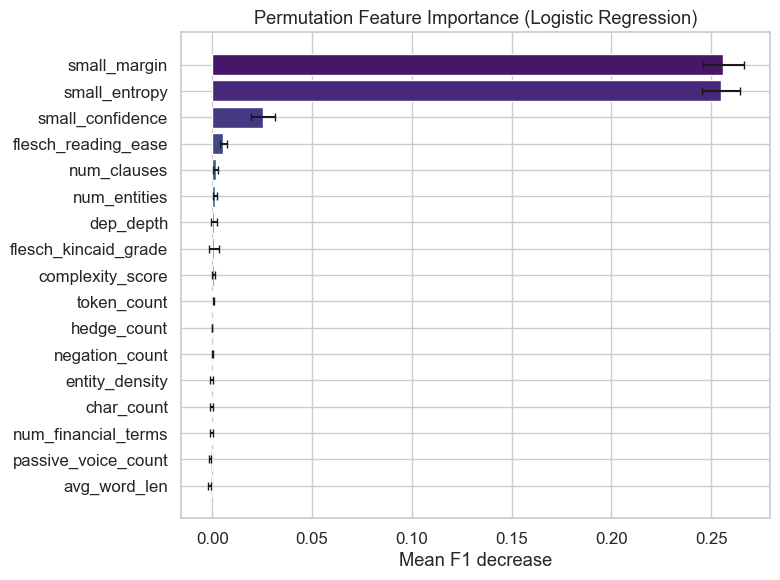

,feature,importance_mean,importance_std
0,small_margin,0.256185,0.010120
1,small_entropy,0.254752,0.009489
2,small_confidence,0.025457,0.006035
3,flesch_reading_ease,0.005619,0.001836
4,num_clauses,0.001772,0.001358
5,num_entities,0.001432,0.001070
6,dep_depth,0.001030,0.001518
7,flesch_kincaid_grade,0.000958,0.002388
8,complexity_score,0.000699,0.000823
9,token_count,0.000578,0.000298


In [29]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(best_pipe, X_train, y_train, n_repeats=10,
                              random_state=42, scoring='f1', n_jobs=-1)

feat_imp = pd.DataFrame({
    'feature': ROUTER_FEATURES,
    'importance_mean': perm.importances_mean,
    'importance_std':  perm.importances_std,
}).sort_values('importance_mean', ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
y_pos = np.arange(len(feat_imp))
ax.barh(y_pos, feat_imp['importance_mean'].values,
        xerr=feat_imp['importance_std'].values,
        color=sns.color_palette('viridis', len(feat_imp)), capsize=3)
ax.set_yticks(y_pos)
ax.set_yticklabels(feat_imp['feature'].values)
ax.invert_yaxis()
ax.set_title(f'Permutation Feature Importance ({best_name})')
ax.set_xlabel('Mean F1 decrease')
plt.tight_layout()
plt.savefig(os.path.join(ROUTER_OUTPUT_DIR, 'feature_importance.png'), dpi=150,
            bbox_inches='tight')
plt.show()

display(feat_imp.reset_index(drop=True))

---

## 9. Inference on test set (small-model signals only)

The router only sees **linguistic features + TinyBERT confidence signals**.  
No large-model information is available at inference time.

In [30]:
df_test = build_merged_df(TEST_CSV, SMALL_TEST_PREDS_CSV)

X_test = df_test[ROUTER_FEATURES].values

print(f'Test set shape : {df_test.shape}')
print(f'X_test shape   : {X_test.shape}')
print(f'\nSmall-model accuracy on test: {df_test["small_correct"].mean():.4f}')

Test set shape : (6223, 21)
X_test shape   : (6223, 17)

Small-model accuracy on test: 0.7964


In [31]:
df_test['router_decision'] = best_pipe.predict(X_test)
df_test['router_prob']     = best_pipe.predict_proba(X_test)[:, 1]

escalation_rate = df_test['router_decision'].mean()
print(f'Router escalation rate on test: {escalation_rate:.2%}')
print(f'  Kept by small model : {(df_test["router_decision"] == 0).sum()}')
print(f'  Escalated to large  : {(df_test["router_decision"] == 1).sum()}')

Router escalation rate on test: 33.68%
  Kept by small model : 4127
  Escalated to large  : 2096


## 10. Simulate routing & evaluate (using large-model test preds for comparison only)

In [32]:
df_large_test = pd.read_csv(LARGE_TEST_PREDS_CSV)[['id', 'pred_label', 'correct']].copy()
df_large_test.rename(columns={'pred_label': 'large_pred', 'correct': 'large_correct'}, inplace=True)

df_test = df_test.merge(df_large_test, on='id', how='inner')
df_test['large_correct'] = df_test['large_correct'].astype(int)

df_test['routed_pred'] = np.where(
    df_test['router_decision'] == 1,
    df_test['large_pred'],
    df_test['small_pred']
)
df_test['routed_correct'] = (df_test['routed_pred'] == df_test['true_label']).astype(int)

df_test['escalate_oracle'] = (
    (df_test['small_correct'] == 0) & (df_test['large_correct'] == 1)
).astype(int)
oracle_pred = np.where(df_test['escalate_oracle'] == 1,
                       df_test['large_pred'], df_test['small_pred'])
df_test['oracle_correct'] = (oracle_pred == df_test['true_label']).astype(int)

print('Merge & simulation done.')

Merge & simulation done.


In [33]:
small_acc  = df_test['small_correct'].mean()
large_acc  = df_test['large_correct'].mean()
routed_acc = df_test['routed_correct'].mean()
oracle_acc = df_test['oracle_correct'].mean()

true_ids   = df_test['true_label'].map(LABEL2ID)
small_f1   = f1_score(true_ids, df_test['small_pred'].map(LABEL2ID),  average='weighted')
large_f1   = f1_score(true_ids, df_test['large_pred'].map(LABEL2ID),  average='weighted')
routed_f1  = f1_score(true_ids, df_test['routed_pred'].map(LABEL2ID), average='weighted')
oracle_f1  = f1_score(true_ids, pd.Series(oracle_pred).map(LABEL2ID), average='weighted')

# ── Computational cost model ──
# Relative cost: small model = 1 unit, large model = C units.
# TinyBERT ~14M params, RoBERTa-large ~355M params → ratio ≈ 25×.
COST_SMALL = 1.0
COST_LARGE = 25.0

def compute_cost_metrics(large_usage_frac):
    """Given fraction of samples sent to large model, return cost metrics."""
    avg_cost = (1 - large_usage_frac) * COST_SMALL + large_usage_frac * COST_LARGE
    cost_reduction = 1.0 - avg_cost / COST_LARGE
    return avg_cost, cost_reduction

n = len(df_test)

small_large_usage  = 0.0
large_large_usage  = 1.0
router_large_usage = escalation_rate
oracle_large_usage = df_test['escalate_oracle'].mean()

small_avg_cost,  small_cost_red  = compute_cost_metrics(small_large_usage)
large_avg_cost,  large_cost_red  = compute_cost_metrics(large_large_usage)
router_avg_cost, router_cost_red = compute_cost_metrics(router_large_usage)
oracle_avg_cost, oracle_cost_red = compute_cost_metrics(oracle_large_usage)

results = pd.DataFrame([
    {'Strategy': 'Small only (TinyBERT)',  'Accuracy': small_acc,  'Weighted F1': small_f1,
     'Large-Model Usage': small_large_usage,  'Avg Cost (units)': small_avg_cost,  'Cost Reduction vs Large-Only': small_cost_red},
    {'Strategy': 'Large only (RoBERTa)',   'Accuracy': large_acc,  'Weighted F1': large_f1,
     'Large-Model Usage': large_large_usage,  'Avg Cost (units)': large_avg_cost,  'Cost Reduction vs Large-Only': large_cost_red},
    {'Strategy': f'Router ({best_name})',  'Accuracy': routed_acc, 'Weighted F1': routed_f1,
     'Large-Model Usage': router_large_usage, 'Avg Cost (units)': router_avg_cost, 'Cost Reduction vs Large-Only': router_cost_red},
    {'Strategy': 'Oracle (upper bound)',   'Accuracy': oracle_acc, 'Weighted F1': oracle_f1,
     'Large-Model Usage': oracle_large_usage, 'Avg Cost (units)': oracle_avg_cost, 'Cost Reduction vs Large-Only': oracle_cost_red},
])

fmt = results.copy()
fmt['Accuracy']                    = fmt['Accuracy'].map('{:.4f}'.format)
fmt['Weighted F1']                 = fmt['Weighted F1'].map('{:.4f}'.format)
fmt['Large-Model Usage']           = fmt['Large-Model Usage'].map('{:.2%}'.format)
fmt['Avg Cost (units)']            = fmt['Avg Cost (units)'].map('{:.2f}'.format)
fmt['Cost Reduction vs Large-Only'] = fmt['Cost Reduction vs Large-Only'].map('{:.2%}'.format)

display(fmt)

,Strategy,Accuracy,Weighted F1,Large-Model Usage,Avg Cost (units),Cost Reduction vs Large-Only
0,Small only (TinyBERT),0.7964,0.7974,0.00%,1.00,96.00%
1,Large only (RoBERTa),0.8764,0.8763,100.00%,25.00,0.00%
2,Router (Logistic Regression),0.8596,0.8595,33.68%,9.08,63.67%
3,Oracle (upper bound),0.9197,0.9197,12.33%,3.96,84.17%


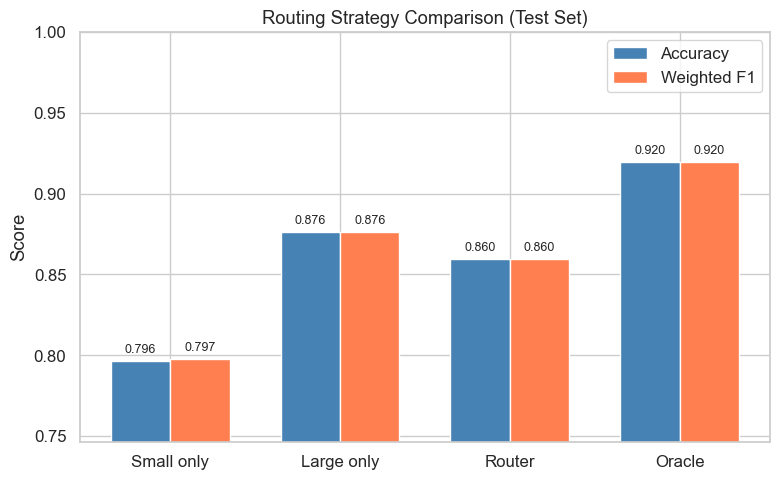

In [34]:
fig, ax = plt.subplots(figsize=(8, 5))
strategies = ['Small only', 'Large only', 'Router', 'Oracle']
accs  = [small_acc, large_acc, routed_acc, oracle_acc]
f1s   = [small_f1, large_f1, routed_f1, oracle_f1]

x = np.arange(len(strategies))
w = 0.35
bars1 = ax.bar(x - w/2, accs, w, label='Accuracy', color='steelblue')
bars2 = ax.bar(x + w/2, f1s,  w, label='Weighted F1', color='coral')

ax.set_ylabel('Score')
ax.set_title('Routing Strategy Comparison (Test Set)')
ax.set_xticks(x)
ax.set_xticklabels(strategies)
ax.legend()
ax.set_ylim(min(accs + f1s) - 0.05, 1.0)

for bar_group in [bars1, bars2]:
    for bar in bar_group:
        h = bar.get_height()
        ax.annotate(f'{h:.3f}', xy=(bar.get_x() + bar.get_width() / 2, h),
                    xytext=(0, 4), textcoords='offset points',
                    ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(ROUTER_OUTPUT_DIR, 'routing_comparison.png'), dpi=150,
            bbox_inches='tight')
plt.show()

## 11. Computational cost–accuracy trade-off curve

Sweep the router's escalation probability threshold from 0 → 1.
At each threshold, compute **accuracy**, **weighted F1**, **large-model usage %**, and **average computational cost**.
Lower threshold = more escalation (higher cost, potentially higher accuracy).

In [35]:
thresholds = np.linspace(0, 1, 201)
router_probs = df_test['router_prob'].values

curve_rows = []
for t in thresholds:
    decisions = (router_probs >= t).astype(int)
    preds = np.where(decisions == 1, df_test['large_pred'].values, df_test['small_pred'].values)
    correct = (preds == df_test['true_label'].values)
    acc = correct.mean()
    wf1 = f1_score(df_test['true_label'].map(LABEL2ID),
                   pd.Series(preds).map(LABEL2ID), average='weighted')
    usage = decisions.mean()
    avg_cost, cost_red = compute_cost_metrics(usage)
    curve_rows.append({
        'threshold': t, 'accuracy': acc, 'weighted_f1': wf1,
        'large_usage': usage, 'avg_cost': avg_cost, 'cost_reduction': cost_red,
    })

df_curve = pd.DataFrame(curve_rows)

# Mark the operating point of the default threshold (0.5)
op_idx = (df_curve['threshold'] - 0.5).abs().idxmin()
op = df_curve.iloc[op_idx]

print(f'Curve computed over {len(thresholds)} thresholds.')
print(f'Default operating point (t=0.50): acc={op["accuracy"]:.4f}, '
      f'F1={op["weighted_f1"]:.4f}, large usage={op["large_usage"]:.2%}, '
      f'cost reduction={op["cost_reduction"]:.2%}')

Curve computed over 201 thresholds.
Default operating point (t=0.50): acc=0.8596, F1=0.8595, large usage=33.68%, cost reduction=63.67%


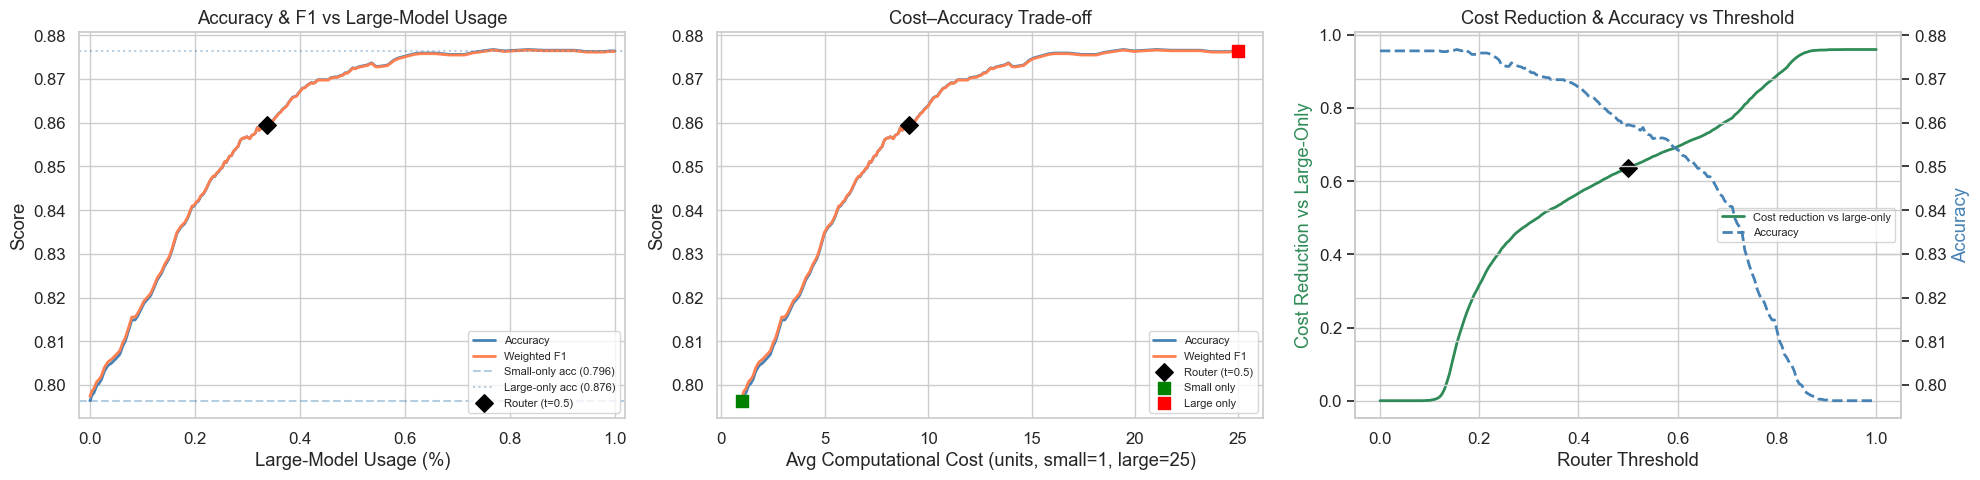

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# ── Plot 1: Accuracy & F1 vs Large-Model Usage ──
ax = axes[0]
ax.plot(df_curve['large_usage'], df_curve['accuracy'], label='Accuracy', color='steelblue', lw=2)
ax.plot(df_curve['large_usage'], df_curve['weighted_f1'], label='Weighted F1', color='coral', lw=2)
ax.axhline(small_acc, color='steelblue', ls='--', alpha=0.4, label=f'Small-only acc ({small_acc:.3f})')
ax.axhline(large_acc, color='steelblue', ls=':', alpha=0.4, label=f'Large-only acc ({large_acc:.3f})')
ax.scatter([op['large_usage']], [op['accuracy']], zorder=5, s=80, color='black', marker='D', label=f'Router (t=0.5)')
ax.set_xlabel('Large-Model Usage (%)')
ax.set_ylabel('Score')
ax.set_title('Accuracy & F1 vs Large-Model Usage')
ax.legend(fontsize=8, loc='lower right')
ax.set_xlim(-0.02, 1.02)

# ── Plot 2: Accuracy vs Avg Computational Cost ──
ax = axes[1]
ax.plot(df_curve['avg_cost'], df_curve['accuracy'], color='steelblue', lw=2, label='Accuracy')
ax.plot(df_curve['avg_cost'], df_curve['weighted_f1'], color='coral', lw=2, label='Weighted F1')
ax.scatter([op['avg_cost']], [op['accuracy']], zorder=5, s=80, color='black', marker='D', label=f'Router (t=0.5)')
ax.scatter([COST_SMALL], [small_acc], zorder=5, s=80, color='green', marker='s', label='Small only')
ax.scatter([COST_LARGE], [large_acc], zorder=5, s=80, color='red', marker='s', label='Large only')
ax.set_xlabel(f'Avg Computational Cost (units, small=1, large={COST_LARGE:.0f})')
ax.set_ylabel('Score')
ax.set_title('Cost–Accuracy Trade-off')
ax.legend(fontsize=8, loc='lower right')

# ── Plot 3: Cost Reduction vs Threshold ──
ax = axes[2]
ax.plot(df_curve['threshold'], df_curve['cost_reduction'], color='seagreen', lw=2, label='Cost reduction vs large-only')
ax2 = ax.twinx()
ax2.plot(df_curve['threshold'], df_curve['accuracy'], color='steelblue', lw=2, ls='--', label='Accuracy')
ax.scatter([op['threshold']], [op['cost_reduction']], zorder=5, s=80, color='black', marker='D')
ax.set_xlabel('Router Threshold')
ax.set_ylabel('Cost Reduction vs Large-Only', color='seagreen')
ax2.set_ylabel('Accuracy', color='steelblue')
ax.set_title('Cost Reduction & Accuracy vs Threshold')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='center right')

plt.tight_layout()
plt.savefig(os.path.join(ROUTER_OUTPUT_DIR, 'cost_accuracy_curves.png'), dpi=150,
            bbox_inches='tight')
plt.show()

In [37]:
curve_path = os.path.join(ROUTER_OUTPUT_DIR, 'cost_accuracy_curve.csv')
df_curve.to_csv(curve_path, index=False)
print(f'Saved → {curve_path}  ({len(df_curve)} rows)')

Saved → /Users/tejeshwinirs/Documents/Projects/UMN/NLP/Linguistically-aware-model-routing-for-financial-sentiment-analysis/Output/router_outputs/cost_accuracy_curve.csv  (201 rows)


## 12. Per-class breakdown (test set)

=== Routed system — per-class report (test) ===
              precision    recall  f1-score   support

    negative       0.82      0.82      0.82      1343
     neutral       0.87      0.85      0.86      2143
    positive       0.87      0.88      0.88      2737

    accuracy                           0.86      6223
   macro avg       0.85      0.85      0.85      6223
weighted avg       0.86      0.86      0.86      6223



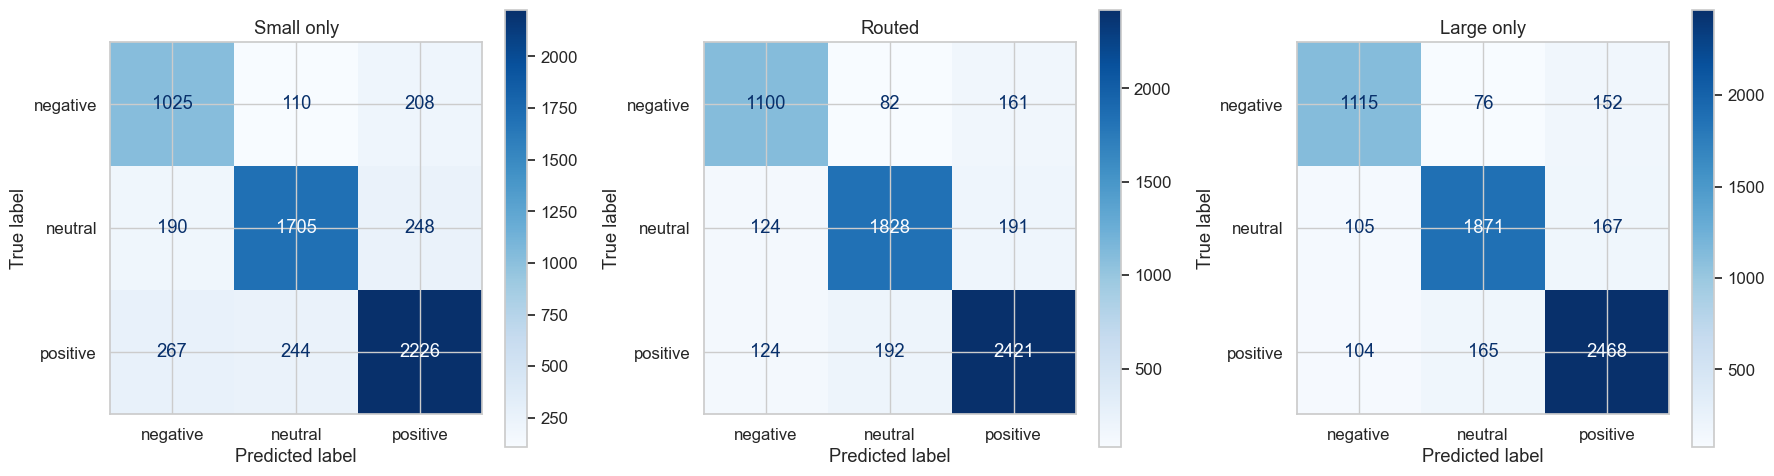

In [38]:
print('=== Routed system — per-class report (test) ===')
print(classification_report(
    df_test['true_label'], df_test['routed_pred'], target_names=LABEL_NAMES
))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (title, pred_col) in zip(axes, [
    ('Small only', 'small_pred'),
    ('Routed', 'routed_pred'),
    ('Large only', 'large_pred'),
]):
    cm = confusion_matrix(df_test['true_label'], df_test[pred_col], labels=LABEL_NAMES)
    ConfusionMatrixDisplay(cm, display_labels=LABEL_NAMES).plot(ax=ax, cmap='Blues')
    ax.set_title(title)

plt.tight_layout()
plt.savefig(os.path.join(ROUTER_OUTPUT_DIR, 'per_class_confusion.png'), dpi=150,
            bbox_inches='tight')
plt.show()

## 13. Escalation analysis by feature (test set)

In [39]:
escalated = df_test[df_test['router_decision'] == 1]
kept      = df_test[df_test['router_decision'] == 0]

compare = pd.DataFrame({
    'Kept (mean)':      kept[ROUTER_FEATURES].mean(),
    'Escalated (mean)': escalated[ROUTER_FEATURES].mean(),
})
compare['Difference'] = compare['Escalated (mean)'] - compare['Kept (mean)']
compare = compare.sort_values('Difference', key=abs, ascending=False)
display(compare)

,Kept (mean),Escalated (mean),Difference
char_count,92.809305,106.541508,13.732203
flesch_reading_ease,59.928347,63.496002,3.567654
token_count,18.822631,21.620706,2.798075
small_entropy,0.192891,0.673726,0.480834
small_margin,0.922765,0.454332,-0.468433
num_clauses,0.588079,1.020515,0.432437
small_confidence,0.956087,0.703781,-0.252306
flesch_kincaid_grade,7.469998,7.305844,-0.164153
dep_depth,4.356191,4.498569,0.142378
num_entities,2.150715,2.275286,0.124571


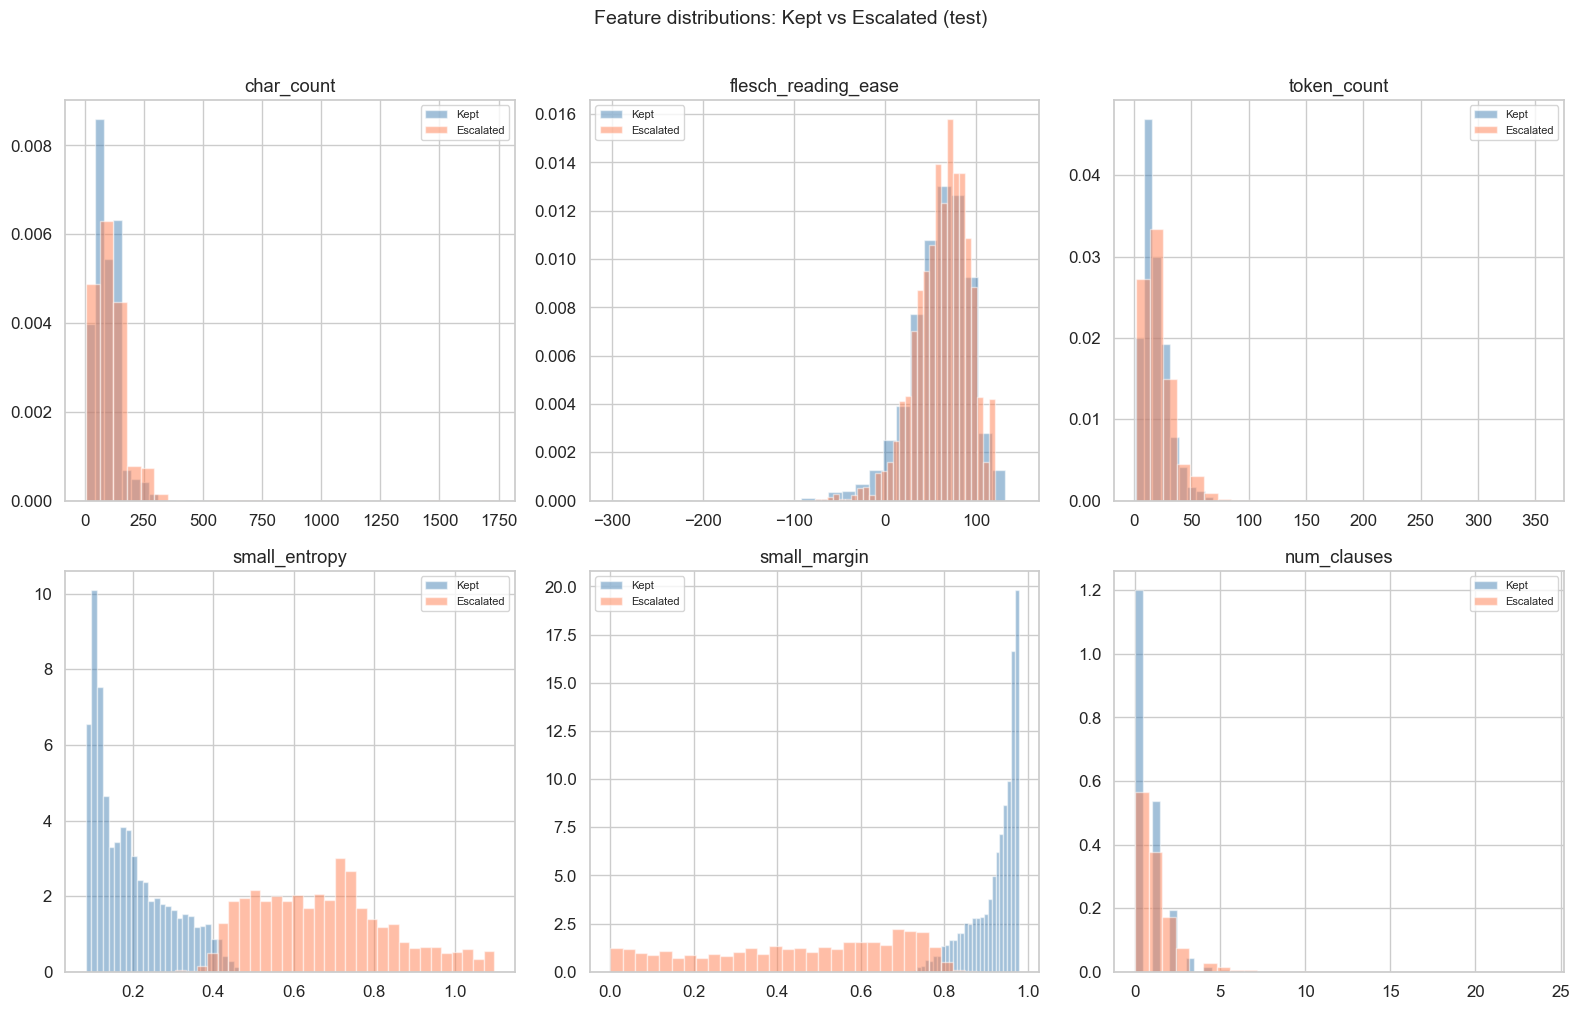

In [40]:
top_features = compare.head(6).index.tolist()
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for ax, feat in zip(axes.flat, top_features):
    for label, sub, color in [
        ('Kept', kept, 'steelblue'), ('Escalated', escalated, 'coral')]:
        ax.hist(sub[feat], bins=30, alpha=0.5, label=label, color=color, density=True)
    ax.set_title(feat)
    ax.legend(fontsize=8)

plt.suptitle('Feature distributions: Kept vs Escalated (test)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(ROUTER_OUTPUT_DIR, 'escalation_distributions.png'), dpi=150,
            bbox_inches='tight')
plt.show()

## 14. Router accuracy — did escalation actually help?

In [41]:
esc = df_test[df_test['router_decision'] == 1]
kpt = df_test[df_test['router_decision'] == 0]

print('Among samples the router ESCALATED:')
print(f'  Small model would have been correct : {esc["small_correct"].sum()} / {len(esc)} '
      f'({esc["small_correct"].mean():.1%})')
print(f'  Large model is correct              : {esc["large_correct"].sum()} / {len(esc)} '
      f'({esc["large_correct"].mean():.1%})')

print(f'\nAmong samples the router KEPT with small model:')
print(f'  Small model is correct : {kpt["small_correct"].sum()} / {len(kpt)} '
      f'({kpt["small_correct"].mean():.1%})')

Among samples the router ESCALATED:
  Small model would have been correct : 1243 / 2096 (59.3%)
  Large model is correct              : 1636 / 2096 (78.1%)

Among samples the router KEPT with small model:
  Small model is correct : 3713 / 4127 (90.0%)


## 15. Save outputs

In [42]:
output_cols = [
    'id', 'true_label', 'small_pred', 'large_pred',
    'small_correct', 'large_correct',
    'router_decision', 'router_prob', 'routed_pred', 'routed_correct',
    'escalate_oracle', 'oracle_correct',
] + ROUTER_FEATURES

out_path = os.path.join(ROUTER_OUTPUT_DIR, 'router_test_predictions.csv')
df_test[output_cols].to_csv(out_path, index=False)
print(f'Saved → {out_path}  ({len(df_test)} rows)')

fmt.to_csv(os.path.join(ROUTER_OUTPUT_DIR, 'routing_strategy_comparison.csv'), index=False)
print(f'Saved → {os.path.join(ROUTER_OUTPUT_DIR, "routing_strategy_comparison.csv")}')

feat_imp.to_csv(os.path.join(ROUTER_OUTPUT_DIR, 'feature_importance.csv'), index=False)
print(f'Saved → {os.path.join(ROUTER_OUTPUT_DIR, "feature_importance.csv")}')

Saved → /Users/tejeshwinirs/Documents/Projects/UMN/NLP/Linguistically-aware-model-routing-for-financial-sentiment-analysis/Output/router_outputs/router_test_predictions.csv  (6223 rows)
Saved → /Users/tejeshwinirs/Documents/Projects/UMN/NLP/Linguistically-aware-model-routing-for-financial-sentiment-analysis/Output/router_outputs/routing_strategy_comparison.csv
Saved → /Users/tejeshwinirs/Documents/Projects/UMN/NLP/Linguistically-aware-model-routing-for-financial-sentiment-analysis/Output/router_outputs/feature_importance.csv


## 16. Summary

| Phase | Data | What happens |
|-------|------|--------------|
| **Training** | val split | Both models' predictions available → build oracle `escalate` label → train router |
| **Inference** | test split | Only linguistic features + TinyBERT signals → router decides keep/escalate |
| **Evaluation** | test split | Large-model test preds used **only** to measure routed accuracy (not seen by router) |

| What | Detail |
|------|--------|
| **Router input** | 14 linguistic features + 3 small-model confidence signals |
| **Oracle label** | `escalate=1` when small is wrong AND large is correct |
| **Classifiers** | Logistic Regression, Random Forest, Gradient Boosting, SVM, MLP |
| **CV** | 5-fold stratified on val set → best by F1 |
| **Metrics** | Accuracy, Weighted F1, Large-Model Usage %, Avg Cost, Cost Reduction vs Large-Only |
| **Cost model** | small = 1 unit, large = 25 units (≈ TinyBERT 14M vs RoBERTa-large 355M params) |
| **Cost–accuracy curve** | Threshold sweep (0→1) showing Pareto trade-off between cost and performance |